In [1]:
# Compare RMSE curves for DQN and MFI on real response data (EXP027).
# Auto-detects every summary CSV of the form
#   summary_real_{DATASET}_DQN_{METHOD}_gamma_{GAMMA}.csv
# and pairs them with the matching MFI baseline
#   summary_real_{DATASET}_MFI_{METHOD}.csv
#
# METHOD_FILTER / GAMMA_FILTER narrow the discovered runs to a specific subset;
# set an entry to None to keep every matching run.
from __future__ import annotations

import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd


def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for root in [cwd, *cwd.parents]:
        if (root / "data").is_dir() and (root / "EXP027").is_dir():
            return root
    raise FileNotFoundError("Run this notebook inside the repository.")


def rmse_at(data: pd.DataFrame, steps: list[int]) -> list[float]:
    integer_steps = data["step"].round().astype(int)
    return [
        float(data.loc[integer_steps == step, "RMSE"].iloc[0])
        if (integer_steps == step).any()
        else float("nan")
        for step in steps
    ]


ROOT = find_project_root()
EXP027_RESULTS = ROOT / "EXP027" / "results"

TEST_LENGTH = 40
KEY_STEPS = [10, 20, 30, 40]
ZOOM_START = 5  # start x-axis at this step in the zoomed plot

# Restrict to MFI (MLE) vs DQN (MLE, gamma=0.3).
METHOD_FILTER: set[str] | None = {"MLE"}
GAMMA_FILTER: set[str] | None = {"0.3"}

print(f"Project root : {ROOT}")
print(f"Results dir  : {EXP027_RESULTS}")
print(f"Methods kept : {METHOD_FILTER if METHOD_FILTER else 'ALL'}")
print(f"Gammas kept  : {GAMMA_FILTER if GAMMA_FILTER else 'ALL'}")

Project root : /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History
Results dir  : /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP027/results
Methods kept : {'MLE'}
Gammas kept  : {'0.3'}


In [2]:
# Discover every (dataset, estimation_method, gamma) DQN run and its MFI pair,
# then apply METHOD_FILTER / GAMMA_FILTER from cell-imports.
dqn_pattern = re.compile(
    r"summary_real_(?P<dataset>.+?)_DQN_(?P<method>.+?)_gamma_(?P<gamma>.+?)\.csv$"
)

runs: dict[tuple[str, str], dict] = {}
for path in sorted(EXP027_RESULTS.glob("summary_real_*_DQN_*_gamma_*.csv")):
    match = dqn_pattern.match(path.name)
    if match is None:
        continue
    dataset = match.group("dataset")
    method = match.group("method")
    gamma = match.group("gamma")
    if METHOD_FILTER is not None and method not in METHOD_FILTER:
        continue
    if GAMMA_FILTER is not None and gamma not in GAMMA_FILTER:
        continue
    key = (dataset, method)
    runs.setdefault(key, {"dataset": dataset, "method": method, "gammas": {}})
    runs[key]["gammas"][gamma] = pd.read_csv(path)

for (dataset, method), run in runs.items():
    mfi_path = EXP027_RESULTS / f"summary_real_{dataset}_MFI_{method}.csv"
    run["mfi"] = pd.read_csv(mfi_path) if mfi_path.exists() else None

if not runs:
    raise FileNotFoundError(
        f"No matching DQN summary CSVs under {EXP027_RESULTS} "
        f"(methods={METHOD_FILTER}, gammas={GAMMA_FILTER})."
    )

for (dataset, method), run in runs.items():
    print(
        f"  dataset={dataset}, method={method}, "
        f"gammas={sorted(run['gammas'])}, "
        f"mfi={'yes' if run['mfi'] is not None else 'NO'}"
    )

  dataset=LNIRT_CredentialForm1, method=MLE, gammas=['0.3'], mfi=yes


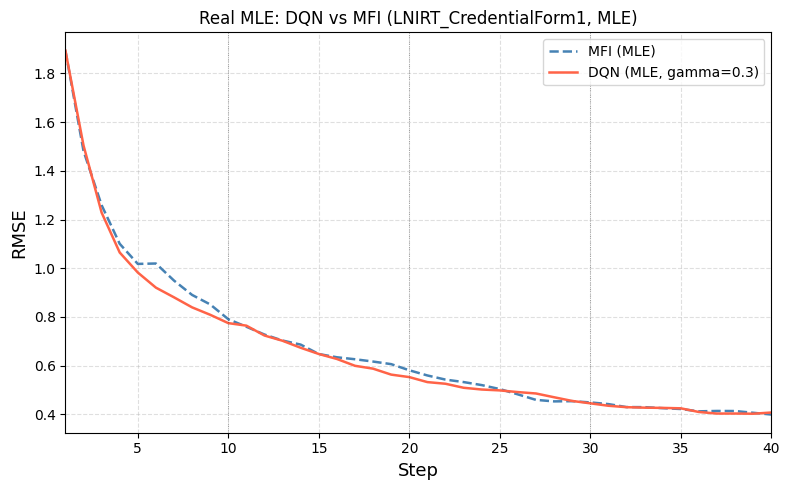

Saved full-range figure to: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP027/results/rmse_comparison_real_full.png


In [3]:
# Full-range figure: one panel per (dataset, method).
# MFI is drawn in steelblue dashed. DQN uses a warm palette (tomato, orange,
# green, purple, ...) so it never collides with MFI's blue.
DQN_COLORS = [
    "tomato",
    "darkorange",
    "seagreen",
    "purple",
    "saddlebrown",
    "deeppink",
    "olive",
    "teal",
]


def draw_panel(axis, run, *, start_step: int = 1):
    if run["mfi"] is not None:
        mfi = run["mfi"]
        subset = mfi[mfi["step"] >= start_step]
        axis.plot(
            subset["step"],
            subset["RMSE"],
            label=f"MFI ({run['method']})",
            color="steelblue",
            linestyle="--",
            linewidth=1.8,
        )
    for i, gamma in enumerate(sorted(run["gammas"])):
        curve = run["gammas"][gamma]
        subset = curve[curve["step"] >= start_step]
        axis.plot(
            subset["step"],
            subset["RMSE"],
            label=f"DQN ({run['method']}, gamma={gamma})",
            color=DQN_COLORS[i % len(DQN_COLORS)],
            linewidth=1.8,
        )
    for step in KEY_STEPS:
        if step >= start_step:
            axis.axvline(step, color="black", linewidth=0.6, linestyle=":", alpha=0.4)
    axis.set_xlabel("Step", fontsize=13)
    axis.set_ylabel("RMSE", fontsize=13)
    axis.grid(True, linestyle="--", alpha=0.4)
    axis.xaxis.set_major_locator(mticker.MultipleLocator(5))
    axis.set_xlim(start_step, TEST_LENGTH)
    axis.legend(fontsize=10)


n_panels = len(runs)
figure, axes = plt.subplots(1, n_panels, figsize=(8 * n_panels, 5), squeeze=False)
for axis, ((dataset, method), run) in zip(axes[0], runs.items()):
    draw_panel(axis, run, start_step=1)
    axis.set_title(f"Real MLE: DQN vs MFI ({dataset}, {method})", fontsize=12)

figure.tight_layout()
EXP027_RESULTS.mkdir(parents=True, exist_ok=True)
full_path = EXP027_RESULTS / "rmse_comparison_real_full.png"
figure.savefig(full_path, dpi=150)
plt.show()
print(f"Saved full-range figure to: {full_path}")

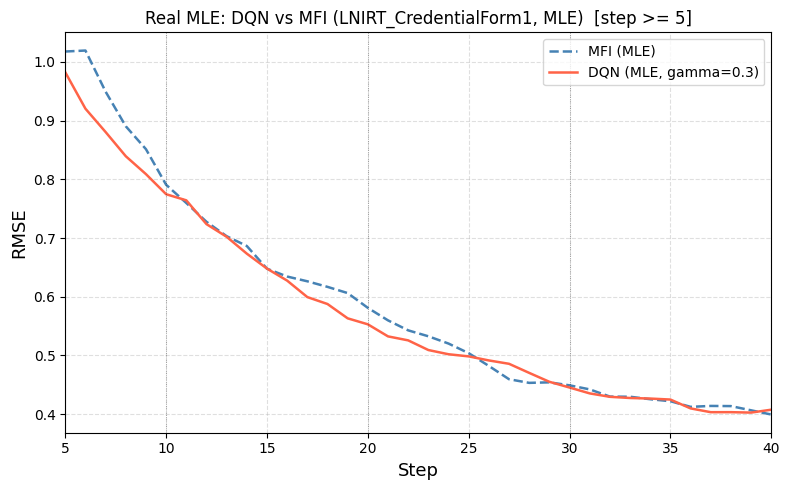

Saved zoomed figure to: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP027/results/rmse_comparison_real_zoom_step5.png


In [4]:
# Zoomed figure starting from step ZOOM_START, since step 1 dominates the scale.
figure, axes = plt.subplots(1, n_panels, figsize=(8 * n_panels, 5), squeeze=False)
for axis, ((dataset, method), run) in zip(axes[0], runs.items()):
    draw_panel(axis, run, start_step=ZOOM_START)
    axis.set_title(
        f"Real MLE: DQN vs MFI ({dataset}, {method})  [step >= {ZOOM_START}]",
        fontsize=12,
    )

figure.tight_layout()
zoom_path = EXP027_RESULTS / f"rmse_comparison_real_zoom_step{ZOOM_START}.png"
figure.savefig(zoom_path, dpi=150)
plt.show()
print(f"Saved zoomed figure to: {zoom_path}")

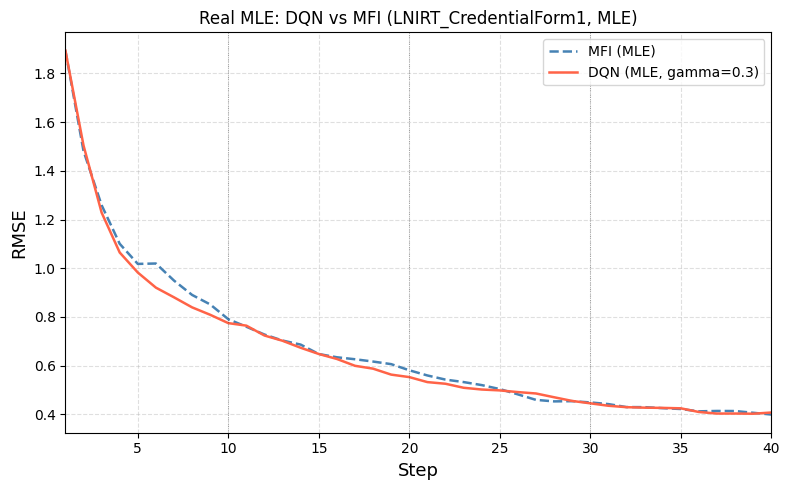

Saved to: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP027/results/rmse_comparison_real_LNIRT_CredentialForm1_MLE_full.png


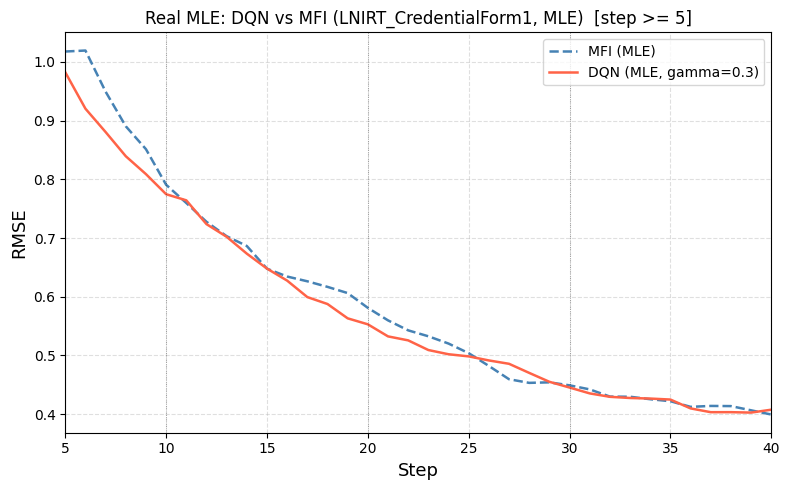

Saved to: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP027/results/rmse_comparison_real_LNIRT_CredentialForm1_MLE_zoom_step5.png


In [5]:
# Save each (dataset, method) panel as its own PNG (full range and zoom).
for (dataset, method), run in runs.items():
    for start_step, kind in [(1, "full"), (ZOOM_START, f"zoom_step{ZOOM_START}")]:
        figure, axis = plt.subplots(figsize=(8, 5))
        draw_panel(axis, run, start_step=start_step)
        suffix = "" if start_step == 1 else f"  [step >= {start_step}]"
        axis.set_title(
            f"Real MLE: DQN vs MFI ({dataset}, {method}){suffix}", fontsize=12
        )
        figure.tight_layout()
        output_path = (
            EXP027_RESULTS / f"rmse_comparison_real_{dataset}_{method}_{kind}.png"
        )
        figure.savefig(output_path, dpi=150)
        plt.show()
        print(f"Saved to: {output_path}")

In [6]:
# RMSE at key steps for each series.
rows = []
for (dataset, method), run in runs.items():
    if run["mfi"] is not None:
        rows.append(
            {
                "dataset": dataset,
                "method": method,
                "series": f"MFI ({method})",
                **dict(zip(KEY_STEPS, rmse_at(run["mfi"], KEY_STEPS))),
            }
        )
    for gamma in sorted(run["gammas"]):
        rows.append(
            {
                "dataset": dataset,
                "method": method,
                "series": f"DQN ({method}, gamma={gamma})",
                **dict(zip(KEY_STEPS, rmse_at(run["gammas"][gamma], KEY_STEPS))),
            }
        )

comparison = pd.DataFrame(rows).set_index(["dataset", "method", "series"])
comparison.columns.name = "step"
print(comparison.to_string(float_format="{:.3f}".format))

step                                                 10    20    30    40
dataset               method series                                      
LNIRT_CredentialForm1 MLE    MFI (MLE)            0.791 0.581 0.449 0.399
                             DQN (MLE, gamma=0.3) 0.775 0.553 0.445 0.407
